# Natural Disaster Tweet Classifier

In this notebook, we develop a Natural Disaster Tweet Classifier. As the name suggests, this model takes a tweet as input and assigns one relevant disaster-related label to it, such as flood, earthquake, wildfire, cyclone or hurricane.

**Importing Useful Libraries**

In [5]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import clickhouse_connect
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import io
import os

# Load .env file
load_dotenv()

# Read environment variables
endpoint = os.getenv("MINIO_ENDPOINT")
access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

In [6]:
# Create one reusable ClickHouse connection for the whole notebook.
client = clickhouse_connect.get_client(
    host="clickhouse",
    port=8123,
    username="analytics",
    password="analytics_secret",
)

We load the fact_tweet_features table from ClickHouse, as it contains all the relevant features required to train the classifier.

In [7]:
# Get all rows of the table fact_tweet_features from ClickHouse
query = """
SELECT *
FROM exploitation_analytics.fact_tweet_features
"""

df = client.query_df(query)

**Exploratory Data Analysis**

The data contains 16 variables in total: 4 categorical variables and 12 numerical variables.

- **tweet_id**: unique identifier of the tweet  
- **disaster_type_key**: encoded key representing the disaster category  
- **disaster_type**: target label indicating the type of disaster (e.g., wildfire, flood, earthquake)
- **emoji_count**: number of emojis in the tweet  
- **tweet_text**: raw text content of the tweet  
- **text_length**: number of characters in the tweet  
- **word_count**: number of words in the tweet  
- **hashtag_count**: number of hashtags used  
- **mention_count**: number of user mentions  
- **url_count**: number of URLs included  
- **exclamation_count**: number of exclamation marks  
- **question_count**: number of question marks  
- **contains_youtube**: binary indicator for presence of YouTube mentions 
- **contains_alert_keyword**: binary indicator for alert-related keywords  
- **simple_sentiment_score**: numerical sentiment score of the tweet  
- **simple_sentiment_label**: categorical sentiment label (e.g., positive, neutral, negative)  

These features capture both structural and semantic properties of the tweets, providing a compact but informative representation for the classification task.

Duplicate rows: 0

=== Missing Values (%) ===
tweet_id                  0.0
disaster_type_key         0.0
disaster_type             0.0
emoji_count               0.0
tweet_text                0.0
text_length               0.0
word_count                0.0
hashtag_count             0.0
mention_count             0.0
url_count                 0.0
exclamation_count         0.0
question_count            0.0
contains_youtube          0.0
contains_alert_keyword    0.0
simple_sentiment_score    0.0
simple_sentiment_label    0.0
dtype: float64

=== Disaster Type Distribution (%) ===
disaster_type
hurricane     40.841547
earthquake    30.565292
flood            14.909
wildfire      10.190783
cyclone        3.493378
Name: proportion, dtype: Float64

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127527 entries, 0 to 127526
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   tweet_id

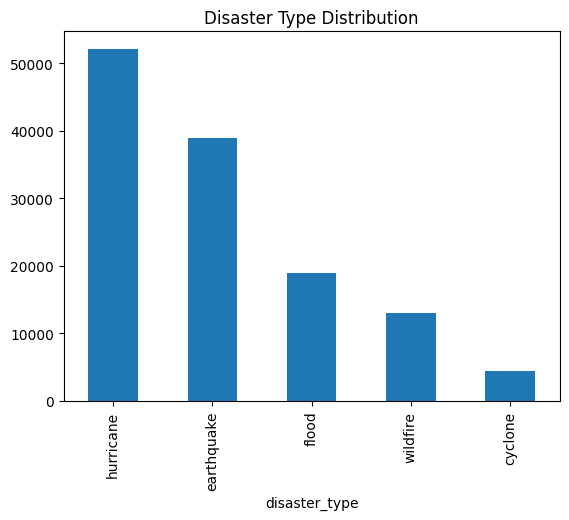

In [8]:
# 1. Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print()

# 2. Missing values
print("=== Missing Values (%) ===")
print((df.isnull().mean() * 100).sort_values(ascending=False))
print()

# 3. Label distribution
print("=== Disaster Type Distribution (%) ===")
print((df["disaster_type"].value_counts(normalize=True) * 100))
print()

# 4. Basic dataset info
print("=== Dataset Info ===")
print(df.info())
print()

# 5. Feature statistics
print("=== Numerical Feature Summary ===")
print(df.describe())
print()

# 6. Binary column sanity check
binary_cols = ["contains_youtube", "contains_alert_keyword"]
for col in binary_cols:
    print(f"{col} values:", df[col].value_counts().to_dict())

print()

# 7. Text sanity checks
print("Empty tweets:", (df["tweet_text"].str.strip() == "").sum())
print("Very short tweets (<5 chars):", (df["tweet_text"].str.len() < 5).sum())
print()

# 8. Label cleanup check
print("Unique disaster types:")
print(df["disaster_type"].unique())
print()

# 9. Quick visualization
plt.figure()
df["disaster_type"].value_counts().plot(kind="bar")
plt.title("Disaster Type Distribution")
plt.show()

There are also separate tables containing hashtags and emojis used in the tweets. In principle, these could have been incorporated as additional features to train the classifier and potentially improve performance. However, since the focus of this work is mainly on data management aspects, we keep the scope limited and only use the data available in the fact table.

Overall, the dataset is clean and well-structured, containing 127,527 records with no missing values or duplicate entries, which indicates strong data quality. The target variable, disaster_type, is moderately imbalanced: hurricanes (40.8%) and earthquakes (30.6%) dominate the distribution, while cyclone represents a small minority class (3.5%), which could introduce some bias toward the majority classes during training if not handled properly. Flood and wildfire fall in between these extremes. From a feature perspective, tweets are relatively short, averaging around 139 characters and 21 words, and they rarely contain URLs, mentions, or YouTube references, which suggests that the dataset is mostly composed of concise text-based messages. Sentiment scores are centered close to zero with a slight positive bias overall, while binary indicators such as contains_youtube and contains_alert_keyword are infrequent but still provide potentially useful signals. Overall, the dataset is clean, diverse in features, and suitable for building a multi-class disaster classification model.

Next, we preprocess the dataset and perform feature selection. For this task, we retain only the raw tweet text and the target variable disaster_type. Although additional engineered features (such as sentiment, counts, hashtags, and emojis) are available, they are ultimately derived from the original text and therefore do not introduce new independent information. The same reasoning applies to auxiliary tables containing hashtags and emojis, which can be seen as alternative representations of the text rather than additional signals. As a result, we deliberately focus on a text-only formulation of the problem to keep the modeling approach simple and aligned with the scope of the project.

**Preprocessing**

In [9]:
# Create a copy of the original dataframe
df_clean = df.copy()

# Remove very short, meaningless tweets
df_clean = df_clean[df_clean["word_count"] > 3]

print(f"Num of rows before preprocessing: {len(df)}")
print(f"Num of rows before preprocessing: {len(df_clean)}")

Num of rows before preprocessing: 127527
Num of rows before preprocessing: 127074


**Training**

In [10]:
# Final dataset
X = df_clean["tweet_text"]
y = df_clean["disaster_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Prediction with Rejection**

To handle out-of-distribution inputs such as irrelevant or non-disaster-related tweets, the model is extended with a rejection mechanism based on prediction confidence. If the maximum class probability falls below a predefined threshold, the system abstains from making a prediction and assigns the label "unknown". This allows the classifier to avoid overconfident predictions on inputs that do not resemble any training distribution.

In [11]:
def predict_with_rejection(texts, threshold=0.6):
    X_vec = vectorizer.transform(texts)
    
    probs = clf.predict_proba(X_vec)
    max_probs = probs.max(axis=1)
    preds = clf.classes_[np.argmax(probs, axis=1)]
    
    final_preds = [
        pred if p >= threshold else "unknown"
        for pred, p in zip(preds, max_probs)
    ]
    
    return final_preds, max_probs

In [12]:
# Sample inputs
samples = [
    "Massive earthquake hits California",
    "hello world",
    "wildfire spreading rapidly near forest"
]

preds, confs = predict_with_rejection(samples, threshold=0.6)

list(zip(samples, preds, confs))

[('Massive earthquake hits California',
  'earthquake',
  np.float64(0.779241113742918)),
 ('hello world', 'unknown', np.float64(0.45499462144068636)),
 ('wildfire spreading rapidly near forest',
  'wildfire',
  np.float64(0.9849287277934564))]

The results show the behaviour of the selective classification mechanism.

For clearly disaster-related inputs (e.g., "Massive earthquake hits California" and "wildfire spreading rapidly near forest"), the model assigns the correct class with high confidence scores (0.78 and 0.99 respectively), indicating strong alignment between the input text and learned patterns.

In contrast, for a non-disaster or out-of-context input such as "hello world", the model produces a relatively low confidence score (0.46), which falls below the rejection threshold. As a result, the prediction is assigned to the "unknown" class.

This demonstrates that the confidence-based rejection mechanism is effective in filtering ambiguous or irrelevant inputs while preserving accurate classification for meaningful disaster-related tweets.